# Task 13B BTK Spectrum: Forward Truth vs Surrogate Prediction

This notebook compares one held-out Task 13B parameter point using:

- **Physical truth chain**: the stored external-forward BTK/AR spectrum referenced by the dataset manifest.
- **Model prediction**: the Task 13 high-accuracy ensemble mean prediction for the same feature row.

The notebook does not regenerate forward data or retrain the model. It only reads returned Task 13B artifacts.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().parent

sys.path.insert(0, str(REPO_ROOT / "src"))

from ar_inverse.surrogate.models import load_surrogate_checkpoint
from ar_inverse.surrogate.train import _feature_from_row

DATASET_MANIFEST = REPO_ROOT / "outputs/datasets/task13_directional_large_accuracy/dataset.json"
ENSEMBLE_MANIFEST = REPO_ROOT / "outputs/checkpoints/task13_directional_high_accuracy_large/ensemble_manifest.json"

ROW_ID = "task13_test_inplane_100_d00_p00_t00"

print(f"repo root: {REPO_ROOT}")
print(f"dataset manifest exists: {DATASET_MANIFEST.exists()}")
print(f"ensemble manifest exists: {ENSEMBLE_MANIFEST.exists()}")

repo root: /home/liubx25/Ni_Research/Projects/AR_surrogate_and_inverse
dataset manifest exists: True
ensemble manifest exists: True


In [2]:
manifest = json.loads(DATASET_MANIFEST.read_text(encoding="utf-8"))
rows = manifest["rows"]
row_by_id = {row["row_id"]: row for row in rows}

if ROW_ID not in row_by_id:
    available_test_rows = [row["row_id"] for row in rows if row["split"] == "test"]
    raise KeyError(f"{ROW_ID!r} not found. Example test rows: {available_test_rows[:10]}")

row = row_by_id[ROW_ID]
forward_output_path = DATASET_MANIFEST.parent / row["forward_output_ref"]["path"]
forward_payload = json.loads(forward_output_path.read_text(encoding="utf-8"))

bias_mev = np.asarray(forward_payload["bias_mev"], dtype=float)
truth = np.asarray(forward_payload["conductance"], dtype=float)
feature = _feature_from_row(row).reshape(1, -1)

print("row_id:", row["row_id"])
print("split:", row["split"])
print("direction:", row["direction"]["direction_regime"])
print("fit controls:", row["controls"]["fit_layer_pairing_controls"])
print("transport controls:", row["controls"]["transport_controls"])
print("forward output:", forward_output_path.relative_to(REPO_ROOT))

row_id: task13_test_inplane_100_d00_p00_t00
split: test
direction: inplane_100_no_spread
fit controls: {'delta_perp_x': -0.07, 'delta_zx_d': 0.06}
transport controls: {'barrier_z': 0.3, 'gamma': 0.8, 'nk': 41, 'temperature_kelvin': 1.8}
forward output: outputs/datasets/task13_directional_large_accuracy/forward_outputs/task13_test_inplane_100_d00_p00_t00.json


In [3]:
ensemble_payload = json.loads(ENSEMBLE_MANIFEST.read_text(encoding="utf-8"))
member_paths = [REPO_ROOT / path for path in ensemble_payload["member_checkpoints"]]

member_predictions = []
for member_path in member_paths:
    model = load_surrogate_checkpoint(member_path)
    member_predictions.append(model.predict(feature, device="cpu")[0])

member_predictions = np.vstack(member_predictions)
prediction = member_predictions.mean(axis=0)
member_std = member_predictions.std(axis=0)
residual = prediction - truth

rmse = float(np.sqrt(np.mean(residual**2)))
max_abs_error = float(np.max(np.abs(residual)))
mean_abs_error = float(np.mean(np.abs(residual)))
mean_member_std = float(np.mean(member_std))
max_member_std = float(np.max(member_std))

print(f"RMSE: {rmse:.8g}")
print(f"mean absolute error: {mean_abs_error:.8g}")
print(f"max absolute error: {max_abs_error:.8g}")
print(f"mean ensemble std: {mean_member_std:.8g}")
print(f"max ensemble std: {max_member_std:.8g}")

RMSE: 0.00043552973
mean absolute error: 0.00030054178
max absolute error: 0.0013174211
mean ensemble std: 0.00041836303
max ensemble std: 0.0016057783


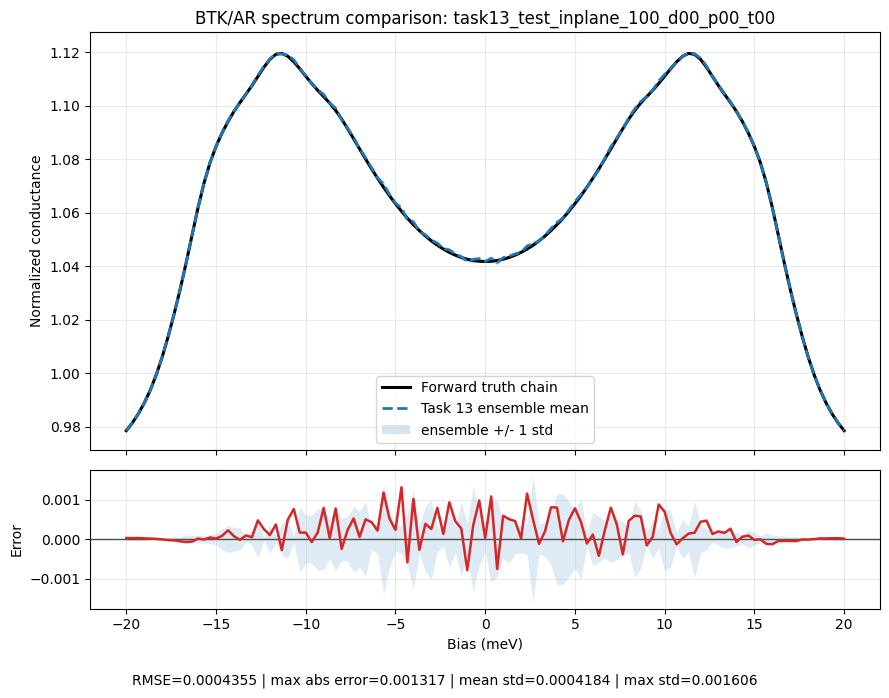

In [4]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax = axes[0]
ax.plot(bias_mev, truth, color="black", linewidth=2.2, label="Forward truth chain")
ax.plot(bias_mev, prediction, color="#1f77b4", linewidth=2.0, linestyle="--", label="Task 13 ensemble mean")
ax.fill_between(
    bias_mev,
    prediction - member_std,
    prediction + member_std,
    color="#1f77b4",
    alpha=0.18,
    linewidth=0,
    label="ensemble +/- 1 std",
)
ax.set_ylabel("Normalized conductance")
ax.set_title(f"BTK/AR spectrum comparison: {ROW_ID}")
ax.legend(loc="best")
ax.grid(True, alpha=0.25)

err_ax = axes[1]
err_ax.axhline(0.0, color="0.3", linewidth=1.0)
err_ax.plot(bias_mev, residual, color="#d62728", linewidth=1.8, label="prediction - truth")
err_ax.fill_between(bias_mev, -member_std, member_std, color="#1f77b4", alpha=0.14, linewidth=0)
err_ax.set_xlabel("Bias (meV)")
err_ax.set_ylabel("Error")
err_ax.grid(True, alpha=0.25)

summary = (
    f"RMSE={rmse:.4g} | max abs error={max_abs_error:.4g} | "
    f"mean std={mean_member_std:.4g} | max std={max_member_std:.4g}"
)
fig.text(0.5, 0.01, summary, ha="center", va="bottom")
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

To inspect another point, change `ROW_ID` in the first code cell to any row id from `outputs/datasets/task13_directional_large_accuracy/dataset.json`, then rerun the notebook.